# 动力学参数辨识
> 重构代码版本，from runModelPulseForce_realconstrast_kc.py


In [1]:
# import
import time
import mujoco
import mujoco.viewer
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import mediapy as media
import datetime
import os
import pandas as pd
import itertools
from tqdm import tqdm
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import scipy
import ipywidgets as widgets
from IPython.display import display
from scipy.optimize import differential_evolution
import cv2
from pathlib import Path


In [2]:
# Tools: 计算长度偏置（初始长度-原长）
def l_calulator(theta_1, theta_2):
    a_1 = 0.25
    a_2 = 0.25
    b_1 = 0.21213
    b_2 = 0.1
    d_1 = 0.06
    d_2 = 0.10

    # 角度参数 (度转弧度)
    beta_1 = 8.13 / 180 * np.pi
    beta_2 = 30 / 180 * np.pi

    A_x_O = d_1
    A_y_O = 0

    B_x_O = -d_2
    B_y_O = 0

    C_x_O = b_1 * np.cos(theta_1 - beta_1)
    C_y_O = b_1 * np.sin(theta_1 - beta_1)

    D_x_O = a_1 * np.cos(theta_1) + b_2 * np.cos(theta_1 + theta_2 + beta_2)
    D_y_O = a_1 * np.sin(theta_1) + b_2 * np.sin(theta_1 + theta_2 + beta_2)

    # 计算长度 l1 和 l2
    l_1 = np.sqrt((A_x_O - C_x_O)**2 + (A_y_O - C_y_O)**2)
    l_2 = np.sqrt((B_x_O - D_x_O)**2 + (B_y_O - D_y_O)**2)

    return l_1, l_2

# Tools: 计算驱动器设置初始偏置 (geom 模型)
def bias_calculator(l_10, l_20):
  l_1, l_2 = l_calulator(math.pi/2, math.pi/2)
  l1_rel = l_10 - l_1
  l2_rel = l_20 - l_2
  return l1_rel/2, l2_rel/2

def smooth_data(data, window_size=5, axis=-1):
    """
    对速度数据进行平滑处理
    Args:
        data: 速度数据，shape为(n_experiments, n_joints, n_timesteps)
        window_size: 滑动窗口大小
    Returns:
        smoothed_data: 平滑后的速度数据
    """
    # 使用边缘处理来避免边缘效应
    pad_width = window_size // 2
    # create the padded axis
    _dim = data.ndim
    _paddle_before_after = [(0,0) for _ in range(_dim)]
    _paddle_before_after[-1] = (pad_width, window_size-pad_width-1)     # the size = data_size + pad_size - window_size + 1
    padded_data = np.pad(data, _paddle_before_after, mode='edge')
    
    return np.apply_along_axis(
        lambda x: np.convolve(x, np.ones(window_size)/window_size, mode='valid'),   # 严格使用卷积
        axis=axis,
        arr=padded_data
    )

In [3]:
# real data: 真实实验数据处理

start_time = time.time()
start_step_time = 5
pressure_group_num = 6
data_real_path = '../data/Archive/A2Bdata/ToCenter_2025-02-20_21-06-20_A2B_data.csv'

# 原始数据：角度为 deg, 具有 pressure1_start, pressure2_start, pressure1_end, pressure2_end, relative_time, thigh_theta21, calf_theta32
data_real = pd.read_csv(data_real_path)    # Goup 3
data_real["experiment_group"] = data_real.groupby(["pressure1_start", "pressure2_start", "pressure1_end", 
                                     "pressure2_end"]).ngroup()
group_data_real_dic = {}    # using group_id to get the group_data_real
expdata_real_lineInterp = []
expdata_real_splineInterp = []
expdata_real_origin = []     # original data
for group_id in data_real["experiment_group"].unique():
    # 访问某组数据
    group_data_real = data_real[data_real["experiment_group"]==group_id]
    group_data_real = group_data_real[group_data_real["relative_time"]>=start_step_time]
    pressure1_start = group_data_real["pressure1_start"].iloc[0]    # 访问group 参数
    pressure2_start = group_data_real["pressure2_start"].iloc[0]
    pressure1_end = group_data_real["pressure1_end"].iloc[0]
    pressure2_end = group_data_real["pressure2_end"].iloc[0]
    time_real = np.array(group_data_real["relative_time"]-start_step_time)  # 访问实验数据
    theta1_real = np.array(group_data_real["thigh_theta21"])
    theta2_real = np.array(group_data_real["calf_theta32"])

    t_intervel = np.linspace(0, 4, 401)
    delta_t = time_real[-1] - time_real[0]

    theta1_real_lineInterp = np.interp(t_intervel, time_real, theta1_real)
    theta2_real_lineInterp = np.interp(t_intervel, time_real, theta2_real)

    theta1_spline = scipy.interpolate.make_interp_spline(time_real, theta1_real, k=3)
    theta2_spline = scipy.interpolate.make_interp_spline(time_real, theta2_real, k=3)
    theta1_real_splineInterp = theta1_spline(t_intervel)
    theta2_real_splineInterp = theta2_spline(t_intervel) 

    expdata_real_lineInterp_one = np.stack((t_intervel, theta1_real_lineInterp, theta2_real_lineInterp), axis=0)
    expdata_real_splineInterp_one = np.stack((t_intervel, theta1_real_splineInterp, theta2_real_splineInterp), axis=0)
    expdata_real_origin_one = np.stack((time_real, theta1_real, theta2_real), axis=0)
    expdata_real_lineInterp.append(expdata_real_lineInterp_one)
    expdata_real_splineInterp.append(expdata_real_splineInterp_one)
    expdata_real_origin.append(expdata_real_origin_one)

expdata_real_lineInterp = np.array(expdata_real_lineInterp)
expdata_real_splineInterp = np.array(expdata_real_splineInterp)
# expdata_real_origin = np.array(expdata_real_origin)       # for the length of each group is different, so we can't use np.array
print(f"expdata_real_lineInterp.shape: {expdata_real_lineInterp.shape}")
print(f"expdata_real_splineInterp.shape: {expdata_real_splineInterp.shape}")
print(f"expdata_real_origin.shape: {len(expdata_real_origin)}")

# real experiment setting
data = pd.read_csv("../log/realdata/StaticProcess/real_StaticPoint_6group_2025-02-21_08-55-07.csv")
P1_array = data['P1'].values
P2_array = data['P2'].values
theta1_array = data['theta1'].values
theta2_array = data['theta2'].values
P1_array_all = np.linspace(0, 50, 6)
P2_array_all = np.linspace(0, 50, 6)

# 实验数据
# theta1_array = np.array(theta1_array, dtype=np.float32)*np.pi/180  # 输入 theta1
# theta2_array = np.array(theta2_array, dtype=np.float32)*np.pi/180  # 输入 theta2
P1_array = np.array(P1_array, dtype=np.float32)*1000  # 实验输出 P
P2_array = np.array(P2_array, dtype=np.float32)*1000  # 实验输出 P

effective_idx = np.array((P1_array/10000) * pressure_group_num + (P2_array/10000), dtype=np.int16)
print("有效索引: ", effective_idx)

# effective_idx = [19]  # TODO 30,10

expdata_real_lineInterp_effective = expdata_real_lineInterp[effective_idx]
expdata_real_splineInterp_effective = expdata_real_splineInterp[effective_idx]
expdata_real_origin_effective = [expdata_real_origin[i] for i in effective_idx]
print(f"expdata_real_lineInterp_effective Shape = {expdata_real_lineInterp_effective.shape}")
print(f"expdata_real_splineInterp_effective Shape = {expdata_real_splineInterp_effective.shape}")
print(f"expdata_real_origin_effective Shape = {len(expdata_real_origin_effective)}")


expdata_real_lineInterp.shape: (36, 3, 401)
expdata_real_splineInterp.shape: (36, 3, 401)
expdata_real_origin.shape: 36
有效索引:  [ 0  1  2  3  6  7  8 12 13 18 19 24 30]
expdata_real_lineInterp_effective Shape = (13, 3, 401)
expdata_real_splineInterp_effective Shape = (13, 3, 401)
expdata_real_origin_effective Shape = 13


In [4]:
# show the real data
# 创建一个滑块来选择感兴趣的组
interest_group_slider = widgets.IntSlider(value=0, min=0, max=len(expdata_real_lineInterp_effective)-1, step=1, description='Interest Group:')
window_size_slider = widgets.IntSlider(value=5, min=1, max=20, step=1, description='Window Size:')

def update_plot(interest_group, window_size=5):
    fig, ax = plt.subplots(2, 1, figsize=(8, 6))

    # # 在图中展示当前选择组的气压值
    # plt.text(0.02, 0.98, f'P1 = {P1_array[interest_group]/1000:.2f} kPa', transform=plt.gca().transAxes)
    # plt.text(0.02, 0.93, f'P2 = {P2_array[interest_group]/1000:.2f} kPa', transform=plt.gca().transAxes)

    # plt.subplot(2, 1, 1)  # 创建一个2行1列的子图，选择第二个子图
    expdata_effective = expdata_real_lineInterp_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='blue', linestyle=':', alpha=0.3, label=r'Line Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='orange', linestyle=':', alpha=0.3, label=r'Line Interpolated $\theta_2$')

    expdata_effective = expdata_real_splineInterp_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='green', alpha=0.3, linestyle="--", label=r'Spline Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='red', alpha=0.3, linestyle="--", label=r'Spline Interpolated $\theta_2$')

    expdata_effective = expdata_real_origin_effective[interest_group]
    ax[0].plot(expdata_effective[0], expdata_effective[1], color='blue', alpha=0.3, linestyle='-', label=r'Real $\theta_1$')
    ax[0].plot(expdata_effective[0], expdata_effective[2], color='orange', alpha=0.3, linestyle='-', label=r'Real $\theta_2$')

    # plot the smooth data of the expdata_real_lineInterp_effective
    expdata_effective = expdata_real_lineInterp_effective[interest_group]
    theta1_smooth = smooth_data(expdata_effective[1][np.newaxis, :], window_size=window_size)[0]
    theta2_smooth = smooth_data(expdata_effective[2][np.newaxis, :], window_size=window_size)[0]
    print(theta1_smooth.shape)
    ax[0].plot(expdata_effective[0], theta1_smooth, color='blue', linestyle='-', label=r'Smooth Line Interpolated $\theta_1$')
    ax[0].plot(expdata_effective[0], theta2_smooth, color='orange', linestyle='-', label=r'Smooth Line Interpolated $\theta_2$')

    ax[0].set_title('Real Data, Line Interpolated and Spline Interpolated Data')
    # ax[0].set_xlabel('Time (s)')
    ax[0].set_ylabel('Angle (deg)')
    ax[0].set_xlim(0, 2)
    ax[0].set_ylim(0, 120)
    ax[0].legend(loc='upper right', fontsize='medium', frameon=True)
    ax[0].grid()
    plt.tight_layout()

    # 利用中心差分计算速度
    velocity1 = np.gradient(theta1_smooth, axis=-1)/delta_t
    velocity2 = np.gradient(theta2_smooth, axis=-1)/delta_t
    # plt.subplot(2, 1, 2)  # 创建一个2行1列的子图，选择第二个子图
    ax[1].plot(expdata_effective[0], velocity1, color='blue', linestyle='-', label=r'Velocity $\theta_1$')
    ax[1].plot(expdata_effective[0], velocity2, color='orange', linestyle='-', label=r'Velocity $\theta_2$')
    ax[1].set_title('Velocity of Angles')
    ax[1].set_xlabel('Time (s)')
    ax[1].set_ylabel('Velocity (deg/s)')
    ax[1].set_xlim(0, 2)
    ax[1].set_ylim(-0.5, 0.5)
    ax[1].legend(loc='upper right', fontsize='medium', frameon=True)
    ax[1].grid()

    plt.show()

# 绑定滑块的值变化到更新函数
widgets.interactive(update_plot, interest_group=interest_group_slider, window_size=window_size_slider)


interactive(children=(IntSlider(value=0, description='Interest Group:', max=12), IntSlider(value=5, descriptio…

(13, 3, 401)


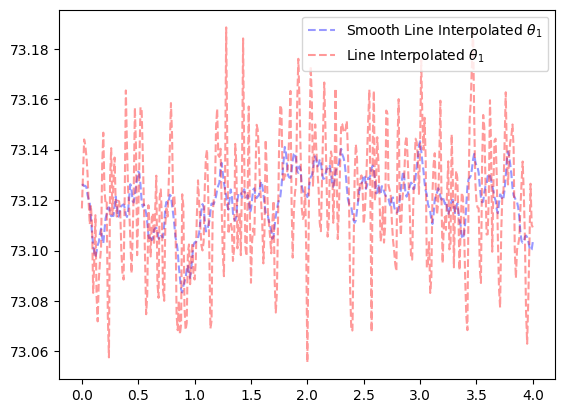

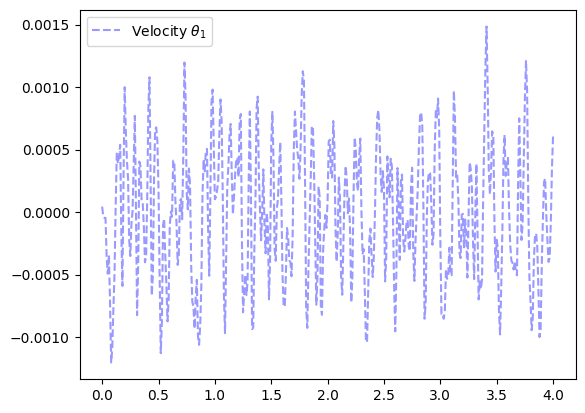

In [5]:
# 实验数据再处理：滑动平均
expdata_real_lineInterp_effective_smooth = smooth_data(expdata_real_lineInterp_effective, window_size=11, axis=-1)
velocity_real_lineInterp_effective_presmooth = np.gradient(expdata_real_lineInterp_effective_smooth, axis=-1)/delta_t
print(expdata_real_lineInterp_effective_smooth.shape)
plt.plot(expdata_real_lineInterp_effective[0, 0], expdata_real_lineInterp_effective_smooth[0, 1], color='blue', alpha=0.4, linestyle='--', label=r'Smooth Line Interpolated $\theta_1$')
plt.plot(expdata_real_lineInterp_effective[0, 0], expdata_real_lineInterp_effective[0, 1], color='red', alpha=0.4, linestyle='--', label=r'Line Interpolated $\theta_1$')
plt.legend()

plt.figure()
plt.plot(expdata_real_lineInterp_effective[0, 0], velocity_real_lineInterp_effective_presmooth[0, 1], color='blue', alpha=0.4, linestyle='--', label=r'Velocity $\theta_1$')
plt.legend()


In [6]:
# sim data
# 仿真数据采集
path = "../models/v2_4/urdf/dog2_4singleLeg_realconstrast.xml"

ExpName = f"AtoB_realsim_constrast_{datetime.datetime.now().strftime('%Y%m%d%H%M%S')}"
m = mujoco.MjModel.from_xml_path(path)
d = mujoco.MjData(m)

RB_BAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_SlideJoint")
RB_BAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_BAA_FM_SlideJoint")
RB_MAA_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_SlideJoint")
RB_MAA_FM_SlideJoint_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_MAA_FM_SlideJoint")
RB_shoulder_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_shoulder")
RB_Elbow_id = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_JOINT, "RB_Elbow")

# NOTE: 注意这里是双层 try and else ~
def run_single_experiment(params, P1, P2):
    """
    单次实验运行函数
    :param params: 包含(damping_MAA, damping_BAA, exp_id)的元组
    """
    try:
        stiffness_MAA, stiffness_BAA, l10, l20, damping_MAA, damping_BAA, s1, s2, c1_thigh, c2_calf = params
        ForcePulse = np.array([P1 * s1, P2 * s2])
        
        m = mujoco.MjModel.from_xml_path(path)
        d = mujoco.MjData(m)

        # 设置刚度和阻尼
        for joint_id, stiffness, damping in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [stiffness_BAA, stiffness_BAA, stiffness_MAA, stiffness_MAA],
            [damping_BAA, damping_BAA, damping_MAA, damping_MAA]
        ):
            m.jnt_stiffness[joint_id] = stiffness * 2
            m.dof_damping[joint_id] = damping * 2

        MAA_bias, BAA_bias = bias_calculator(l10, l20)
        for joint_id, bias in zip(
            [RB_BAA_SlideJoint_id, RB_BAA_FM_SlideJoint_id, RB_MAA_SlideJoint_id, RB_MAA_FM_SlideJoint_id],
            [BAA_bias, BAA_bias, MAA_bias, MAA_bias]
        ):
            m.qpos_spring[joint_id] = bias

        m.dof_damping[RB_shoulder_id] = c1_thigh
        m.dof_damping[RB_Elbow_id] = c2_calf

        d.ctrl = np.zeros_like(d.ctrl)
        mujoco.mj_step(m, d)

        # Experiment Settings
        ExpResultList = []
        time_exp = 20
        time_step = 10

        start = d.time
        try:
            while (d.time - start) < time_exp:  # viewer.is_running() and
                elapsed_time = d.time - start

                if 0 < elapsed_time < time_step:  # 稳定时间
                    d.ctrl[:2] = ForcePulse[0]
                    d.ctrl[2:] = ForcePulse[1]
                elif time_step <= elapsed_time < time_exp:  # 稳定时间
                    d.ctrl[:] = 0  # 同时将所有控制信号置为0

                    # Trick: 由于实际数据稳定，所以这里只记录10s后的模拟数据，如果开始不收敛一定10s后的误差也很大
                    Position = np.array(d.qpos)
                    res = np.hstack((d.time, Position))
                    ExpResultList.append(res)

                mujoco.mj_step(m, d)  # update!

        # # 按住ctrl C退出循环
        except KeyboardInterrupt:
            pass
        
        # data process
        result_array = np.array(ExpResultList)
        time_sim = result_array[:,0]-time_step
        theta1_sim = (result_array[:,1]+math.pi/2)*180/np.pi
        theta2_sim = (result_array[:,2]+math.pi/2)*180/np.pi
        return time_sim, theta1_sim, theta2_sim
    
    except Exception as e:
        print(f"Error: {e}")
        raise e

In [7]:
# 一组初始值
k1 = 141.02960841103112
k2 = 113.79784850542735
l10 = 0.164
l20 = 0.252
c1 = 24.1515
c2 = 10.3101
s1 = 0.0003538647203395966
s2 = 0.0003466318012150854
c1_thigh = 4.9746
c2_calf = 0.3958

In [8]:
# 手动调试工具

# 创建滑动条控件
k1_slider = widgets.FloatSlider(value=k1, min=0, max=700, step=1, description='k1')
k2_slider = widgets.FloatSlider(value=k2, min=0, max=700, step=1, description='k2')
l1_slider = widgets.FloatSlider(value=l10, min=0, max=1, step=0.01, description='l1')
l2_slider = widgets.FloatSlider(value=l20, min=0, max=1, step=0.01, description='l2')
s1_slider = widgets.FloatSlider(value=s1, min=0, max=0.005, step=0.0001, description='s1')
s2_slider = widgets.FloatSlider(value=s2, min=0, max=0.005, step=0.0001, description='s2')
c1_slider = widgets.FloatSlider(value=c1, min=0, max=100, step=1, description='c1')
c2_slider = widgets.FloatSlider(value=c2, min=0, max=100, step=1, description='c2')
c1_thigh_slider = widgets.FloatSlider(value=c1_thigh, min=0, max=100, step=1, description='c1_thigh')
c2_calf_slider = widgets.FloatSlider(value=c2_calf, min=0, max=10, step=0.1, description='c2_calf')

# 选择实验组
interest_group_slider = widgets.IntSlider(value=0, min=0, max=len(expdata_real_lineInterp_effective)-1, step=1, description='Interest Group:')

# 将所有滑动条垂直排列
controls = widgets.VBox([
    interest_group_slider, widgets.HBox([k1_slider, k2_slider]),
    widgets.HBox([l1_slider, l2_slider]), widgets.HBox([s1_slider, s2_slider]),
    widgets.HBox([c1_slider, c2_slider]), widgets.HBox([c1_thigh_slider, c2_calf_slider])
])

# draw
def update_plot_2(interest_group, k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf):
    expdata_effective = expdata_real_lineInterp_effective[interest_group]
    P1 = P1_array[interest_group]
    P2 = P2_array[interest_group]
    para = [k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf]
    time_sim, theta1_sim, theta2_sim = run_single_experiment(para, P1, P2)
    t_intervel = np.linspace(0, 4, 401)
    theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
    theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
    expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0)

    # 创建图形
    # 清空
    # plt.clf()
    plt.figure(figsize=(10, 3))
    
    # 绘制仿真数据
    plt.plot(expdata_sim[0], expdata_sim[1], label=r"$\theta_1-Sim$", color='green', linestyle='-', alpha=0.6)
    plt.plot(expdata_sim[0], expdata_sim[2], label=r"$\theta_2-Sim$", color='red', linestyle='-', alpha=0.6)
    
    # 绘制实验数据
    plt.plot(expdata_effective[0], expdata_effective[1], label=r"$\theta_1-Real$", color='blue', linestyle='-', alpha=0.6)
    plt.plot(expdata_effective[0], expdata_effective[2], label=r"$\theta_2-Real$", color='orange', linestyle='-', alpha=0.6)
    
    # 计算RMSE
    RMSE_THETA1 = np.sqrt(np.mean((expdata_effective[1]-expdata_sim[1])**2))
    RMSE_THETA2 = np.sqrt(np.mean((expdata_effective[2]-expdata_sim[2])**2))

    # 添加标注
    plt.text(0.95, 0.95, f'[{int(P1/1000):d}, {int(P2/1000):d}]->[0, 0] kPa', 
             transform=plt.gca().transAxes, ha='right', va='top', fontsize=12,
             bbox=dict(facecolor='white', alpha=0.5))
    plt.text(0.95, 0.75, f"RMSE1: {RMSE_THETA1:.4f}", transform=plt.gca().transAxes,
             ha='right', va='top', fontsize=12)
    plt.text(0.95, 0.45, f"RMSE2: {RMSE_THETA2:.4f}", transform=plt.gca().transAxes,
             ha='right', va='top', fontsize=12)

    plt.grid(alpha=0.4)
    plt.xlim(0, 4)
    plt.ylim(0, 120)
    plt.xticks(np.arange(0, 4.1, 1))
    plt.yticks(np.arange(0, 120.1, 30))
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (deg)")
    plt.title("Real Data and Sim Data1")
    plt.legend()
    plt.show()

# bind
widgets.interactive(update_plot_2, 
                   interest_group=interest_group_slider,
                   k1=k1_slider,
                   k2=k2_slider, 
                   l10=l1_slider,
                   l20=l2_slider,
                   c1=c1_slider,
                   c2=c2_slider,
                   s1=s1_slider,
                   s2=s2_slider,
                   c1_thigh=c1_thigh_slider,
                   c2_calf=c2_calf_slider)


interactive(children=(IntSlider(value=0, description='Interest Group:', max=12), FloatSlider(value=141.0296084…

In [9]:
# 优化参数
global time_start, time_epi_start, epi
time_start = time.time()
time_epi_start = time.time()
epi = 0

# 在优化开始前创建保存目录
save_dir = Path(f"./optimization_progress_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}")
save_dir.mkdir(exist_ok=True)


In [16]:
typeExp = "static"
# 使用进化算法进行参数优化
def error(params, mode="train", type="static"):
    global typeExp
    typeExp = type
    if type == "static":
      k1, k2, l10, l20, s1, s2 = params
      c1 = 20
      c2 = 20
      c1_thigh = 0
      c2_calf = 0
    else: # static
      k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf = params
    expdata_sim_all = []
    for p1, p2 in zip(P1_array[:], P2_array[:]):
      time_sim, theta1_sim, theta2_sim = run_single_experiment((k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf), p1, p2)
      t_intervel = np.linspace(0, 4, 401)
      theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
      theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
      expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0) 
      expdata_sim_all.append(expdata_sim)
    expdata_sim_all = np.array(expdata_sim_all)

    # Error of theta1 and theta2
    q_errorMat = expdata_sim_all - expdata_real_lineInterp_effective_smooth
    q_SE_mat = q_errorMat**2
    q_MSE_mat = np.mean(q_SE_mat, axis=2)   # along the time axis
    q_MSE_mat_overview = np.mean(q_MSE_mat, axis=0) # along the group axis
    q_MSE_sum = np.mean(q_MSE_mat_overview[1:]) # along the joint axis(MSE of theta1 plus MSE of theta2)

    # Error of angular velocity(vs velocity_real_lineInterp_effective_presmooth)
    qd_sim = np.gradient(expdata_sim_all, axis=-1)/delta_t
    qd_errorMat = qd_sim - velocity_real_lineInterp_effective_presmooth
    qd_SE_mat = qd_errorMat**2
    qd_MSE_mat = np.mean(qd_SE_mat, axis=2)
    qd_MSE_mat_overview = np.mean(qd_MSE_mat, axis=0)
    qd_MSE_sum = np.mean(qd_MSE_mat_overview[1:])   # along the joint axis(MSE of theta1 plus MSE of theta2)
    # print(f"q_MSE_sum: {q_MSE_sum:.4f}, qd_MSE_sum: {qd_MSE_sum:.4f}")
    # velocity_sim_sign = np.where(velocity_sim > 0, 1, -1)
    # velocity_real_sign = np.where(velocity_real > 0, 1, -1)
    # errorMat_velocity = np.where(velocity_sim_sign == velocity_real_sign, 0, 1)

    # error new
    if type == "dynamic":
        return q_MSE_sum + 10000*qd_MSE_sum
    else:
        return np.mean(q_SE_mat[:, 1:, 0])

error([k1, k2, l10, l20, s1, s2], type="static")



np.float64(35.51117849157426)

In [ ]:

# 记录进度
def callback(xk, convergence):
    global time_epi_start, time_epi_start, epi, expdata_real_lineInterp_effective
    epi += 1
    time_cost_epi = time.time() - time_epi_start
    time_epi_start = time.time()
    print(f"Epoch: {epi}, Time/epoch: {time_cost_epi:.2f}s, convergence={convergence:.4f}, MSE={error(xk):.4f}")
    print(f"k1={xk[0]:.4f}, k2={xk[1]:.4f}, l10={xk[2]:.4f}, l20={xk[3]:.4f}, s1={xk[4]:.8f}, s2={xk[5]:.8f}")
    print(f"Time/epoch: {time_cost_epi:.2f}s")
    

bounds = [(k1*0.5, k1*2.5), (k2*0.5, k2*2.5), (l10*0.8, l10*1.2), (l20*0.8, l20*1.2), (s1*0.25, s1*2.5), (s2*0.25, s2*2.5)]  # 每个参数都有10%的变化范围
result = differential_evolution(error, bounds, strategy='best1bin', maxiter=10000, disp=False, callback=callback, popsize=25)


In [17]:

# 记录进度
def callback(xk, convergence):
    global time_epi_start, time_epi_start, epi, expdata_real_lineInterp_effective
    epi += 1
    time_cost_epi = time.time() - time_epi_start
    time_epi_start = time.time()
    print(f"Epoch: {epi}, Time/epoch: {time_cost_epi:.2f}s, convergence={convergence:.4f}, MSE={error(xk):.4f}")
    print(f"k1={xk[0]:.4f}, k2={xk[1]:.4f}, l10={xk[2]:.4f}, l20={xk[3]:.4f}, c1={xk[4]:.4f}, c2={xk[5]:.4f}, s1={xk[6]:.8f}, s2={xk[7]:.8f}, c1_thigh={xk[8]:.4f}, c2_calf={xk[9]:.4f}")
    print(f"Time/epoch: {time_cost_epi:.2f}s")
    
    # 清除当前图形
    plt.clf()
    
    # 创建新的网格布局
    num_experiments = len(expdata_real_lineInterp_effective)
    ncols = 5  # 每行5张图
    nrows = math.ceil(num_experiments / ncols)
    fig = plt.gcf()  # 获取当前图形
    fig.set_size_inches(25, 20)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.05, hspace=0.1, 
                          left=0.08, right=0.99, top=0.9, bottom=0.1)
    
    # 运行所有实验组的仿真
    expdata_sim_all = []
    for p1, p2 in zip(P1_array, P2_array):
        time_sim, theta1_sim, theta2_sim = run_single_experiment(xk, p1, p2)
        t_intervel = np.linspace(0, 4, 401)
        theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
        theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
        expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0)
        expdata_sim_all.append(expdata_sim)
    expdata_sim_all = np.array(expdata_sim_all)

    # 绘制每个实验的对比图
    for exp_id in range(num_experiments):
        ax = fig.add_subplot(gs[exp_id // ncols, exp_id % ncols])
        expdata_real, expdata_sim = expdata_real_lineInterp_effective[exp_id], expdata_sim_all[exp_id]
        
        if exp_id == 0:
            ax.plot(expdata_real[0], expdata_real[1], label=r"$\theta_1-Real$", color='blue', linestyle='-', alpha=0.6)
            ax.plot(expdata_real[0], expdata_real[2], label=r"$\theta_2-Real$", color='orange', linestyle='-', alpha=0.6)
            ax.plot(expdata_sim[0], expdata_sim[1], label=r"$\theta_1-Sim$", color='green', linestyle='-', alpha=0.6)
            ax.plot(expdata_sim[0], expdata_sim[2], label=r"$\theta_2-Sim$", color='red', linestyle='-', alpha=0.6)
        else:
            ax.plot(expdata_real[0], expdata_real[1], color='blue', linestyle='-', alpha=0.6)
            ax.plot(expdata_real[0], expdata_real[2], color='orange', linestyle='-', alpha=0.6)
            ax.plot(expdata_sim[0], expdata_sim[1], color='green', linestyle='-', alpha=0.6)
            ax.plot(expdata_sim[0], expdata_sim[2], color='red', linestyle='-', alpha=0.6)
        
        # 添加标注
        ax.text(0.95, 0.95, f'[{int(P1_array[exp_id]/1000):d}, {int(P2_array[exp_id]/1000):d}]->[0, 0] kPa',
                transform=ax.transAxes, ha='right', va='top', fontsize=12,
                bbox=dict(facecolor='white', alpha=0.5))
        
        # 计算和显示RMSE
        RMSE_THETA1 = np.sqrt(np.mean((expdata_real[1]-expdata_sim[1])**2))
        RMSE_THETA2 = np.sqrt(np.mean((expdata_real[2]-expdata_sim[2])**2))
        ax.text(0.95, 0.75, f"RMSE1: {RMSE_THETA1:.4f}", transform=ax.transAxes,
                ha='right', va='top', fontsize=12)
        ax.text(0.95, 0.45, f"RMSE2: {RMSE_THETA2:.4f}", transform=ax.transAxes,
                ha='right', va='top', fontsize=12)
        
        # 设置轴属性
        ax.grid(alpha=0.4)
        ax.set_xlim(0, 2)
        ax.set_ylim(0, 120)
        ax.set_yticks(np.arange(0, 120.1, 30))
        if exp_id%ncols != 0:   # 如果不在最左边
            ax.set_yticklabels([])
        if exp_id//ncols != nrows-1:  # 如果不在最下面
            ax.set_xticklabels([])
    
    # 添加全局标签和标题
    fig.text(0.5, 0.95, f'优化参数: k1={xk[0]:.4f}, k2={xk[1]:.4f}, l10={xk[2]:.4f}, l20={xk[3]:.4f}, c1={xk[4]:.4f}, c2={xk[5]:.4f}, s1={xk[6]:.8f}, s2={xk[7]:.8f}, c1_thigh={xk[8]:.4f}, c2_calf={xk[9]:.4f}', ha='center', fontsize=20)
    fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=15)
    fig.text(0.04, 0.5, 'Angle (deg)', va='center', rotation='vertical', fontsize=15)
    fig.suptitle(f'Dynamic Test Comparison (Epoch {epi}, Epoch Info, Time/epoch: {time_cost_epi:.2f}s, convergence={convergence:.4f}, MSE={error(xk):.4f})', fontsize=25, y=0.95)
    
    # 添加图例
    handles, labels = [], []
    for ax in fig.axes:
        for handle, label in zip(*ax.get_legend_handles_labels()):
            handles.append(handle)
            labels.append(label)
    fig.legend(handles[:4], labels[:4], bbox_to_anchor=(0.95, 0.3), ncol=1, fontsize=15)
    
    # 调整布局并显示
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    # plt.pause(0.01)  # 暂停一小段时间以显示图形
    # 保存图片而不是显示
    fig_path = save_dir / f"epoch_{epi:04d}.png"
    plt.savefig(fig_path, dpi=100, bbox_inches='tight')
    plt.close(fig)  # 关闭图形，释放内存




bounds = [(k1*0.9, k1*1.5), (k2*0.9, k2*1.5), (l10*0.9, l10*1.1), (l20*0.9, l20*1.1), (0, 30), (0, 30), (s1*0.5, s1*1.5), (s2*0.5, s2*1.5), (0, 5), (0, 5)]  # 每个参数都有10%的变化范围
result = differential_evolution(error, bounds, strategy='best1bin', maxiter=10000, disp=False, callback=callback, popsize=15)
# print the res
k1_opt, k2_opt, l10_opt, l20_opt, c1_opt, c2_opt, s1_opt, s2_opt, c1_thigh_opt, c2_calf_opt = result.x
print(f"Optimal k1={k1_opt:.4f}, k2={k2_opt:.4f}, l10={l10_opt:.4f}, l20={l20_opt:.4f}, c1={c1_opt:.4f}, c2={c2_opt:.4f}, s1={s1_opt:.8f}, s2={s2_opt:.8f}, c1_thigh={c1_thigh_opt:.4f}, c2_calf={c2_calf_opt:.4f}, MSE={result.fun:.4f}")
print(f"Error: {error([k1_opt, k2_opt, l10_opt, l20_opt, c1_opt, c2_opt, s1_opt, s2_opt, c1_thigh_opt, c2_calf_opt])}")
time_cost = time.time() - time_start
print(f"Time Cost: {time_cost:.2f}s")


RuntimeError: The map-like callable must be of the form f(func, iterable), returning a sequence of numbers the same length as 'iterable'

In [ ]:
def make_video(image_folder, video_name='optimization.mp4', fps=5):
    """
    将文件夹中的图片合成为视频
    Args:
        image_folder: 图片文件夹路径
        video_name: 输出视频名称
        fps: 视频帧率
    """
    images = sorted(list(Path(image_folder).glob("epoch_*.png")))
    if not images:
        print("No images found!")
        return
    
    # 读取第一张图片获取尺寸
    frame = cv2.imread(str(images[0]))
    height, width, layers = frame.shape
    
    # 创建视频写入器
    video_path = Path(image_folder) / video_name
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(str(video_path), fourcc, fps, (width, height))
    
    # 将图片写入视频
    for image_path in tqdm(images, desc="Creating video"):
        frame = cv2.imread(str(image_path))
        video.write(frame)
    
    video.release()
    print(f"Video saved to {video_path}")

In [ ]:
make_video("optimization_progress_20250305_231326")

No images found!


In [11]:
# Test: show all the case
para = [k1_opt, k2_opt, l10_opt, l20_opt, c1_opt, c2_opt, s1_opt, s2_opt, c1_thigh_opt, c2_calf_opt]


NameError: name 'k1_opt' is not defined

In [28]:
# 画图：测试一组数据
# set para manually:
# 手动设置参数
k1 = 385.1225
k2 = 335.4172
l10 = 0.1862
l20 = 0.2709
c1 = 24.1515
c2 = 10.3101
s1 = 0.00063079
s2 = 0.00060325
c1_thigh = 4.9746
c2_calf = 0.3958
para = [k1, k2, l10, l20, c1, c2, s1, s2, c1_thigh, c2_calf]

expdata_sim_all = []
for p1, p2 in zip(P1_array, P2_array):
    time_sim, theta1_sim, theta2_sim = run_single_experiment(para, p1, p2)
    t_intervel = np.linspace(0, 4, 401)
    theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
    theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
    expdata_sim = np.stack((t_intervel, theta1_sim_intervel, theta2_sim_intervel), axis=0) 
    expdata_sim_all.append(expdata_sim)
expdata_sim_all = np.array(expdata_sim_all)

print("Error: ", error(para, mode="test", type="dynamic"))


Error:  23.650984273993362


/var/folders/j1/jvx4zg8j2kd3f52pd5cjwjrw0000gn/T/ipykernel_83018/2305982279.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整子图间距，留出空间给图例


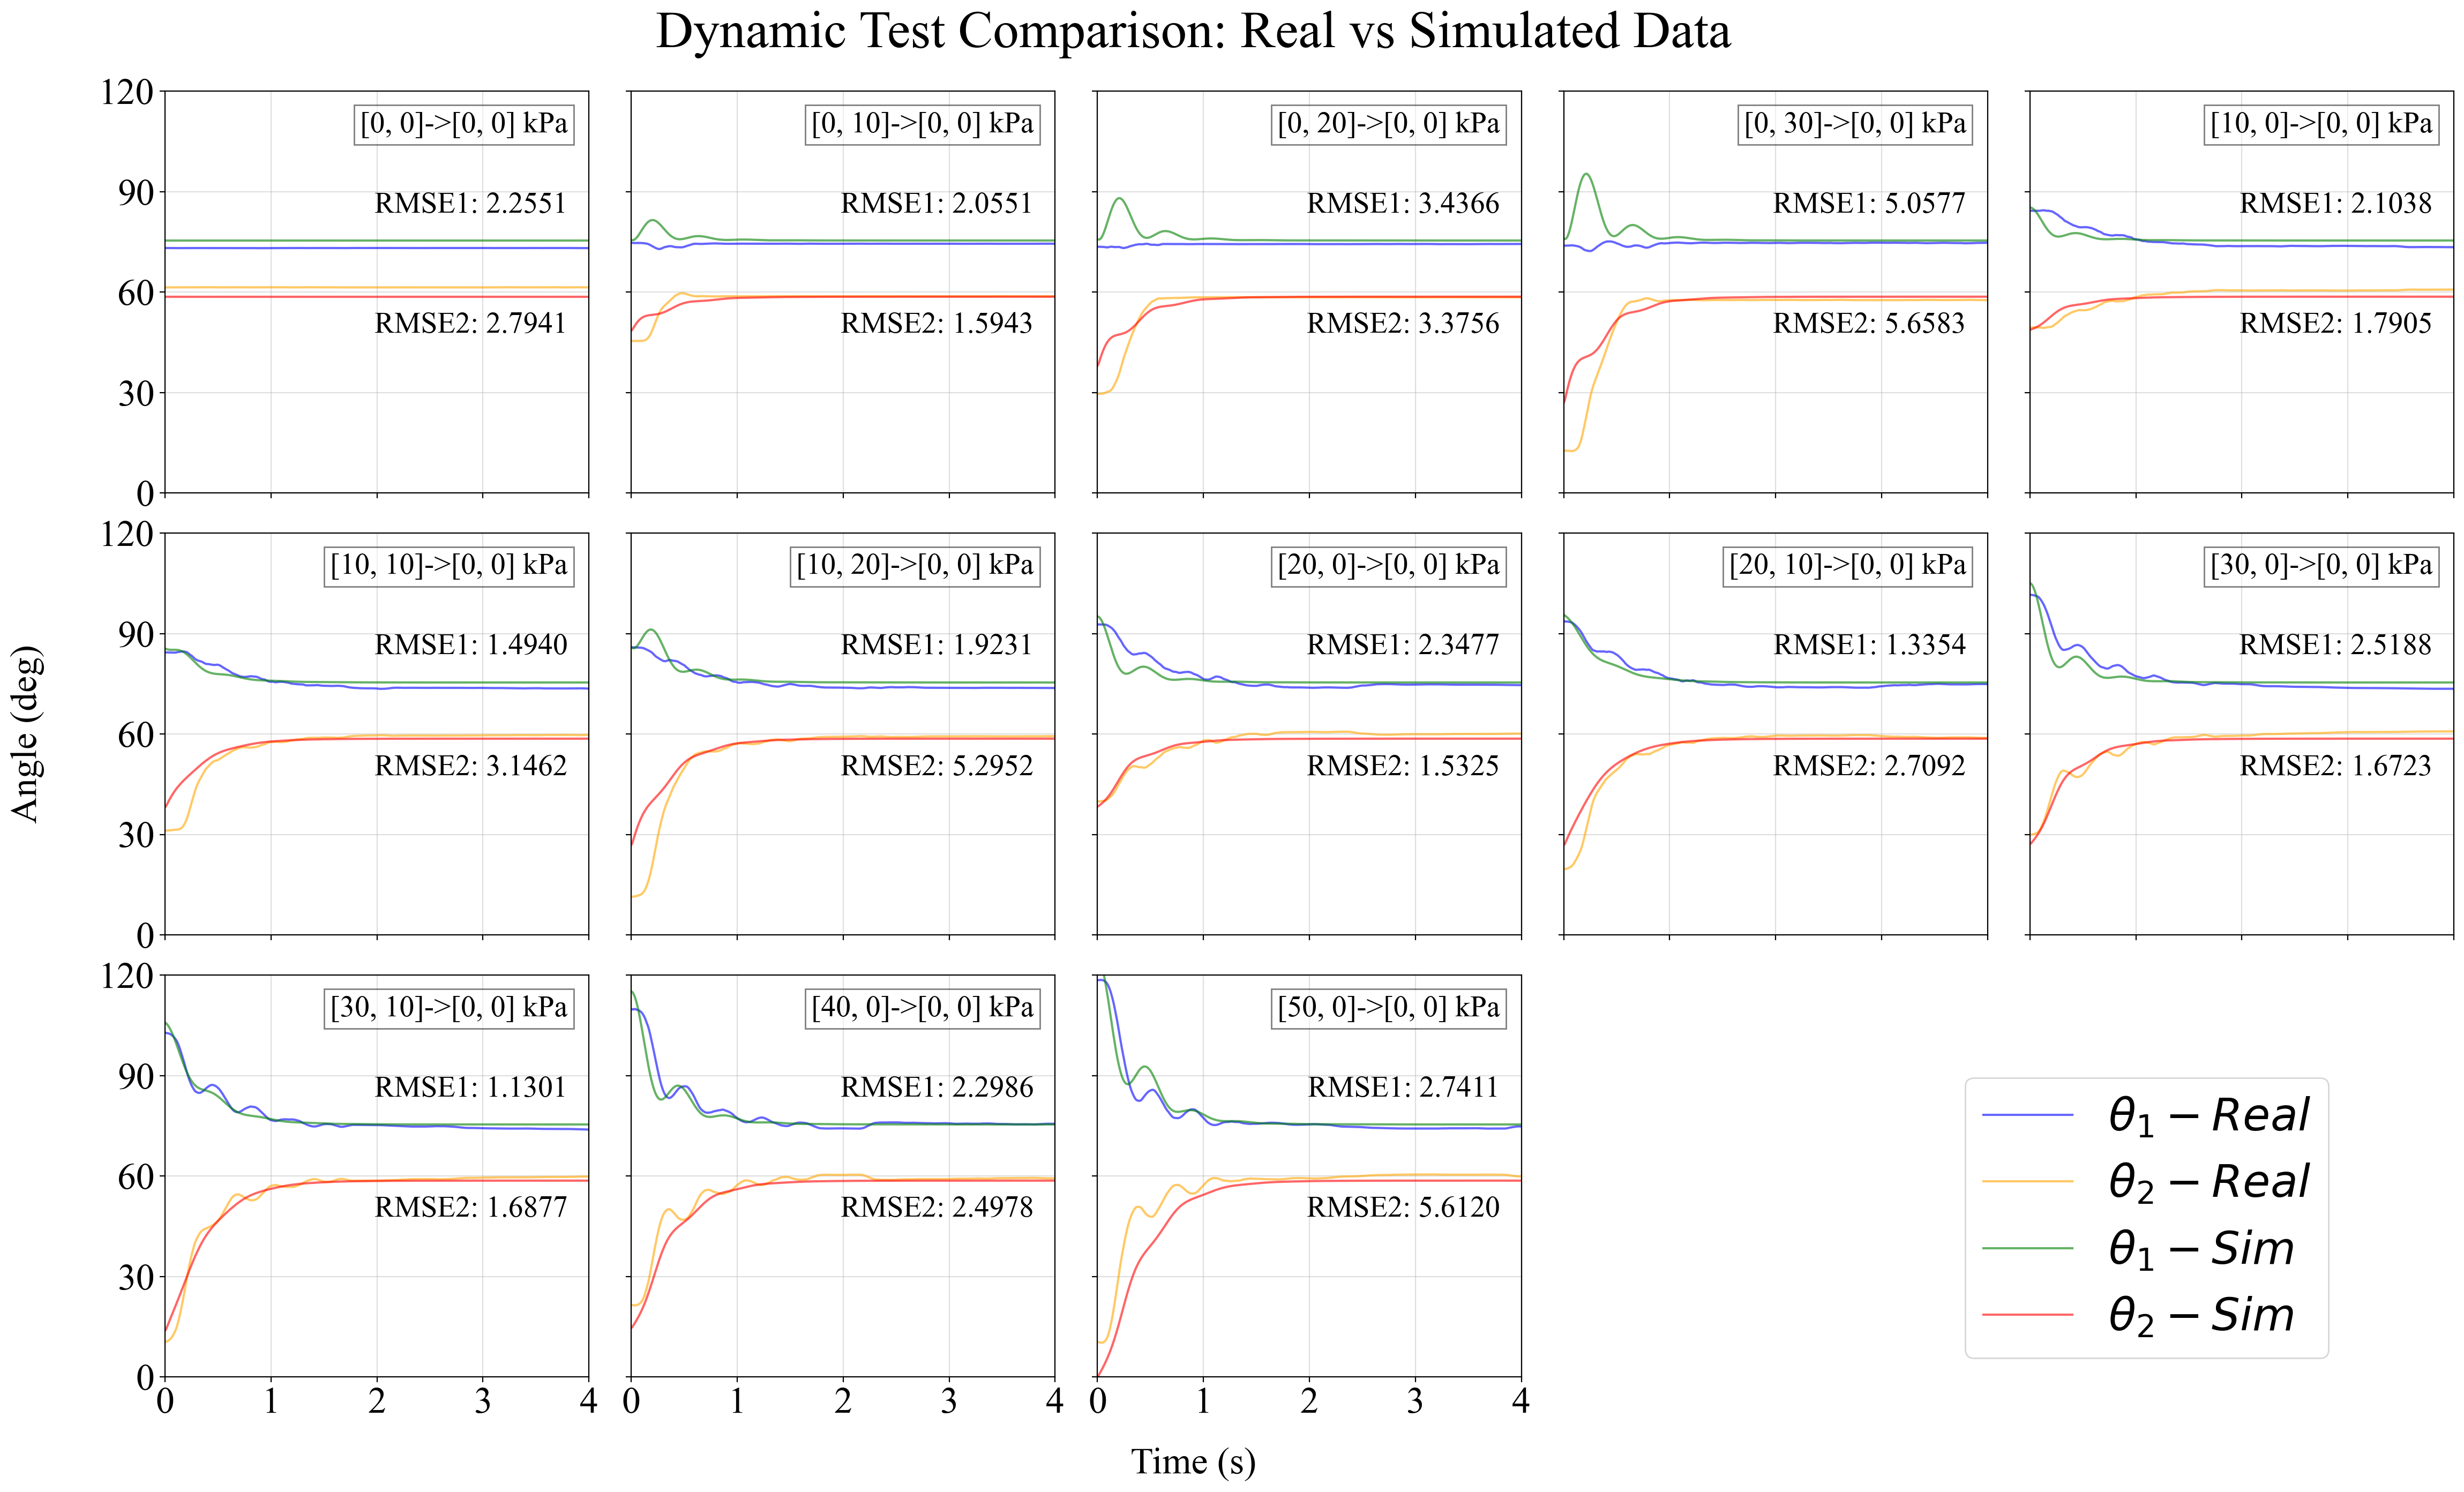

In [56]:

# draw the comparison
# 假设expdata_real_effective和expdata_sim_all是已经定义好的数据
num_experiments = len(expdata_real_lineInterp_effective_smooth)
ncols = 5  # 每行5张图
nrows = math.ceil(num_experiments / ncols)  # 根据实验数计算行数


from matplotlib import rcParams

config = {
    "font.family":'Times New Roman',  # 设置字体类型
    "axes.unicode_minus": False, #解决负号无法显示的问题
    "font.size": 16,  # 设置字体大小
}
rcParams.update(config)

legendSet = {
    # 'loc': 'upper right',
    'fontsize': 30,
}

axisSet = {
    'fontsize': 25,
}

textSet = {
    'fontsize': 20,
}

titleSet = {
    'fontsize': 35,
}

# 创建一个统一的网格布局
fig = plt.figure(figsize=(24, 15), dpi=200)  # 设置整个图形的大小
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.1, hspace=0.1, left=0.1, right=0.99, top=0.9, bottom=0.1)  # 设置子图间距

# 绘制每个实验的图形
for exp_id in range(num_experiments):
    ax = fig.add_subplot(gs[exp_id // ncols, exp_id % ncols])
    expdata_real, expdata_sim = expdata_real_lineInterp_effective_smooth[exp_id], expdata_sim_all[exp_id]
    if exp_id == 0:
        ax.plot(expdata_real[0], expdata_real[1], label=r"$\theta_1-Real$", color='blue', linestyle='-', alpha=0.6)
        ax.plot(expdata_real[0], expdata_real[2], label=r"$\theta_2-Real$", color='orange', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[1], label=r"$\theta_1-Sim$", color='green', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[2], label=r"$\theta_2-Sim$", color='red', linestyle='-', alpha=0.6)
    else:
        ax.plot(expdata_real[0], expdata_real[1], color='blue', linestyle='-', alpha=0.6)
        ax.plot(expdata_real[0], expdata_real[2], color='orange', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[1], color='green', linestyle='-', alpha=0.6)
        ax.plot(expdata_sim[0], expdata_sim[2], color='red', linestyle='-', alpha=0.6)
    # ax.set_title(f"Experiment {exp_id + 1}")
    # 在右上角添加标注
    ax.text(0.95, 0.95, f'[{int(P1_array[exp_id]/1000):d}, {int(P2_array[exp_id]/1000):d}]->[0, 0] kPa', transform=ax.transAxes, 
            ha='right', va='top', fontsize=textSet['fontsize'], bbox=dict(facecolor='white', alpha=0.5))
    # text: RMSE
    RMSE_THETA1 = np.sqrt(np.mean((expdata_real[1]-expdata_sim[1])**2))
    RMSE_THETA2 = np.sqrt(np.mean((expdata_real[2]-expdata_sim[2])**2))
    ax.text(0.95, 0.75, f"RMSE1: {RMSE_THETA1:.4f}", transform=ax.transAxes, 
            ha='right', va='top', fontsize=textSet['fontsize'])
    ax.text(0.95, 0.45, f"RMSE2: {RMSE_THETA2:.4f}", transform=ax.transAxes,
            ha='right', va='top', fontsize=textSet['fontsize'])
    
    ax.grid(alpha=0.4)  # 添加网格线
    ax.set_xlim(0, 4)  # 设置x轴范围
    ax.set_ylim(0, 120)  # 设置y轴范围
    ax.set_xticks(np.arange(0, 4.1, 1))  # 设置x轴刻度
    ax.set_yticks(np.arange(0, 120.1, 30))  # 设置y轴刻度
    # 设置刻度字体大小
    ax.tick_params(axis='both', labelsize=axisSet['fontsize'])  # 12
    if exp_id%ncols != 0:   # 如果不在最左边
        ax.set_yticklabels([])  # 隐藏y轴刻度
    if exp_id//ncols != nrows-1:  # 如果不在最下面
        ax.set_xticklabels([])  # 隐藏x轴刻度


# 设置统一的x轴和y轴标签
fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=axisSet['fontsize'])
fig.text(0.04, 0.5, 'Angle (deg)', va='center', rotation='vertical', fontsize=axisSet['fontsize'])

# 添加全图图名
fig.suptitle('Dynamic Test Comparison: Real vs Simulated Data', fontsize=titleSet['fontsize'], y=0.95)

# 添加统一的图例
handles, labels = [], []
for ax in fig.axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        handles.append(handle)
        labels.append(label)
fig.legend(handles, labels, bbox_to_anchor=(0.95, 0.3), ncol=1, fontsize=legendSet['fontsize'])  # 添加图例

# 调整子图间距
plt.tight_layout(rect=[0, 0, 1, 0.95])  # 调整子图间距，留出空间给图例
plt.show()

